Bontempi, Kivshar et al. "Highly sensitive biosensors based on all-dielectric nanoresonator"
f=1.0, Power_forward= 0.05741638629898457, Power_backward=-0.95735572554837


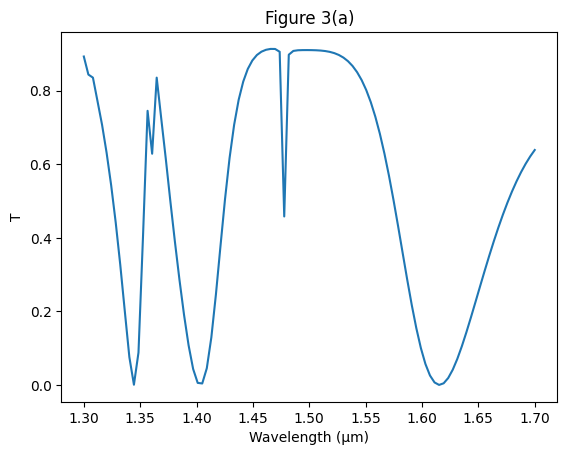

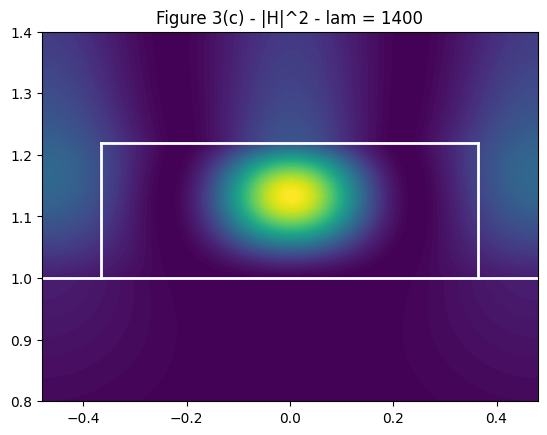

Elapsed time = 7.239132881164551s
If you can read this, the configuration work is finished!


In [1]:

# all lengths normalized in terms of a 
# frequency normalized in terms of 2*pi*c/a

# this test file plots a frequency spectrum and field plot for the python extension

import S4
import numpy as np
import matplotlib.pyplot as plt
import time
from chars import greek, phys

t = time.time()

a = 1e-6; #1nm
c_const = 3e8;
print('Bontempi, Kivshar et al. \"Highly sensitive biosensors based on all-dielectric nanoresonator\"')
p = 0.96
d = 0.73
h = 0.22
period = [p,p]
S = S4.New(Lattice=((period[0],0),(0,period[1])),NumBasis=20)
S.SetMaterial(Name = 'SiO2',Epsilon = (1.45 + 0.0j)**2)
S.SetMaterial(Name = 'Si',Epsilon = (3.487+0.0j)**2)
S.SetMaterial(Name = 'Vacuum',Epsilon = (1 + 0j)**2)

S.AddLayer(Name = 'AirAbove',Thickness = 0, Material = 'Vacuum')
S.AddLayer(Name = 'AirDisp',Thickness = 1, Material = 'Vacuum')
S.AddLayer(Name = 'Si_disks',Thickness = h,Material = 'Vacuum')

S.SetRegionCircle(
    Layer = 'Si_disks',
    Material = 'Si',
    Center = (0,0),
    Radius = d/2
)

S.AddLayer(Name = 'Glass_Below',Thickness = 2, Material = 'SiO2')
#S.AddLayerCopy(Name = 'AirBelow',Thickness = 0, Layer = 'AirAbove')
S.AddLayer(Name = 'AirBelow',Thickness = 0,Material = 'Vacuum')

S.SetExcitationPlanewave(
    IncidenceAngles=(
        0,# polar angle in [0,180)
        0 # azimuthal angle in [0,360)
    ),
    sAmplitude = 0,
    pAmplitude = 1,
    Order = 0
)

S.SetOptions(
    PolarizationDecomposition = True
)

wavelength_um = 1;
freq = 1 / float(wavelength_um);  
S.SetFrequency(freq)  #unit 2*pi*c_const / a
forward,backward = S.GetPowerFlux(Layer = 'AirAbove', zOffset = 0) # reflected power
forward = S.GetPowerFlux(Layer = 'AirBelow',zOffset = 0)
print('f='+str(1/freq)+', Power_forward= '+str(forward[0].real)+', Power_backward='+str(backward.real))

# output POV file
S.OutputStructurePOVRay(Filename = 'output_PythonTest.pov')



# frequency sweep
wavelength_space = np.linspace(1.3, 1.7, 100)

R = wavelength_space * 0
T=R
i=0
for lam in wavelength_space:
    f = 1 / float(lam)
    S.SetFrequency(f)
    (forw,back) = S.GetPowerFlux(Layer = 'AirAbove', zOffset = 0)
    forw = S.GetPowerFlux(Layer = 'AirBelow', zOffset = 0)
    R[i] = np.abs(forw[0])
    #T[i] = np.abs(back)
    i +=1

plt.plot(wavelength_space, R)
#plt.hold
#plt.plot(wavelength_space, T)
plt.xlabel(f'Wavelength ({greek.mu}m)')
plt.ylabel('T')
plt.title('Figure 3(a)')

#field map

wavelength_p_nm = 1400;
wavelength_um = float(wavelength_p_nm)/1000; # [8.0,14.0]
freq = 1 / float(wavelength_um);  
S.SetFrequency(freq)  #unit 2*pi*c_const / a
x_space = np.linspace(-p/2,p/2,200)
z_space = np.linspace(0.8,1.4,200)

X,Z = np.meshgrid(x_space,z_space)
Ey = np.zeros((X.shape[0], X.shape[1]))
xc = 0
zc = 0

for x in x_space:
    zc=0
    #print('x='+str(x)+'\n')
    for z in z_space:
        #print('z='+str(z)+'\tzc='+str(zc)+'\n')
        E,H = S.GetFields(x,0,z)
        Ey[zc,xc] = np.abs(H[1]) ** 2 + np.abs(H[2]) ** 2 + np.abs(H[0]) ** 2
        #print(str(x)+'\t'+str(z)+'\t'+str(abs(E[1])))
        zc += 1
    xc += 1
    
fig = plt.figure()
cm = np.linspace(np.min(Ey),np.max(Ey), 100)
plt.contourf(x_space, z_space, Ey, cm)
plt.plot([-p/2, p/2], [1, 1], color='w', linestyle='-', linewidth=2)
plt.plot([-d/2, d/2], [1+h, 1+h], color='w', linestyle='-', linewidth=2)
plt.plot([-d/2, -d/2], [1, 1+h], color='w', linestyle='-', linewidth=2)
plt.plot([d/2, d/2], [1, 1+h], color='w', linestyle='-', linewidth=2)
plt.title('Figure 3(c) - |H|^2 - lam = ' + str(wavelength_p_nm))
plt.show(block=True)

elapsed = time.time()-t;
print('Elapsed time = '+str(elapsed)+'s')
print('If you can read this, the configuration work is finished!')
